In [8]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for clean, publication-quality plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})

OUTPUT_DIR = './seg_grid_searchNewLosses' 

# Explicitly mapping all 8 rows (listed on the thesis) results table 
target_runs = [
    # ==================== STN REGION ====================
    {
        "label": "STN | Criterion: Dice+HD95+Precision\nUnifiedFocal [64,128,256,512]",
        "matches": ["UnifiedFocal", "f64", "lr0.0005", "drop0.4", "L20.0001", "w0.1-0.9"]
    },
    {
        "label": "STN | Criterion: Dice\nUnifiedFocal [64,128,256,512]",
        "matches": ["UnifiedFocal", "f64", "lr0.0005", "drop0.4", "L20.0001", "w0.1-0.9"]
    },
    {
        "label": "STN | Criterion: HD95\nUnifiedFocal [32,64,128,256]",
        "matches": ["UnifiedFocal", "f32", "lr0.0005", "drop0.4", "L20.0001", "w0.3-0.7"]
    },
    {
        "label": "STN | Criterion: Precision\nUnifiedFocal [64,128,256,512]",
        "matches": ["UnifiedFocal", "f64", "lr0.0005", "drop0.2", "L20.0001", "w0.1-0.9"]
    },
    # ==================== RN REGION ====================
    {
        "label": "RN | Criterion: Dice+HD95+Precision\nFocalTversky [64,128,256,512]",
        "matches": ["FocalTversky", "f64", "lr0.0005", "drop0.2", "L20.01", "w0.1-0.9"]
    },
    {
        "label": "RN | Criterion: Dice\nFocalTversky [64,128,256,512]",
        "matches": ["FocalTversky", "f64", "lr0.0005", "drop0.2", "L20.01", "w0.1-0.9"]
    },
    {
        "label": "RN | Criterion: HD95\nUnifiedFocal [64,128,256,512]",
        "matches": ["UnifiedFocal", "f64", "lr0.0005", "drop0.4", "L20.01", "w0.1-0.9"]
    },
    {
        "label": "RN | Criterion: Precision\nUnifiedFocal [32,64,128,256]",
        "matches": ["UnifiedFocal", "f32", "lr0.0005", "drop0.4", "L20.0001", "w0.1-0.9"]
    }
]

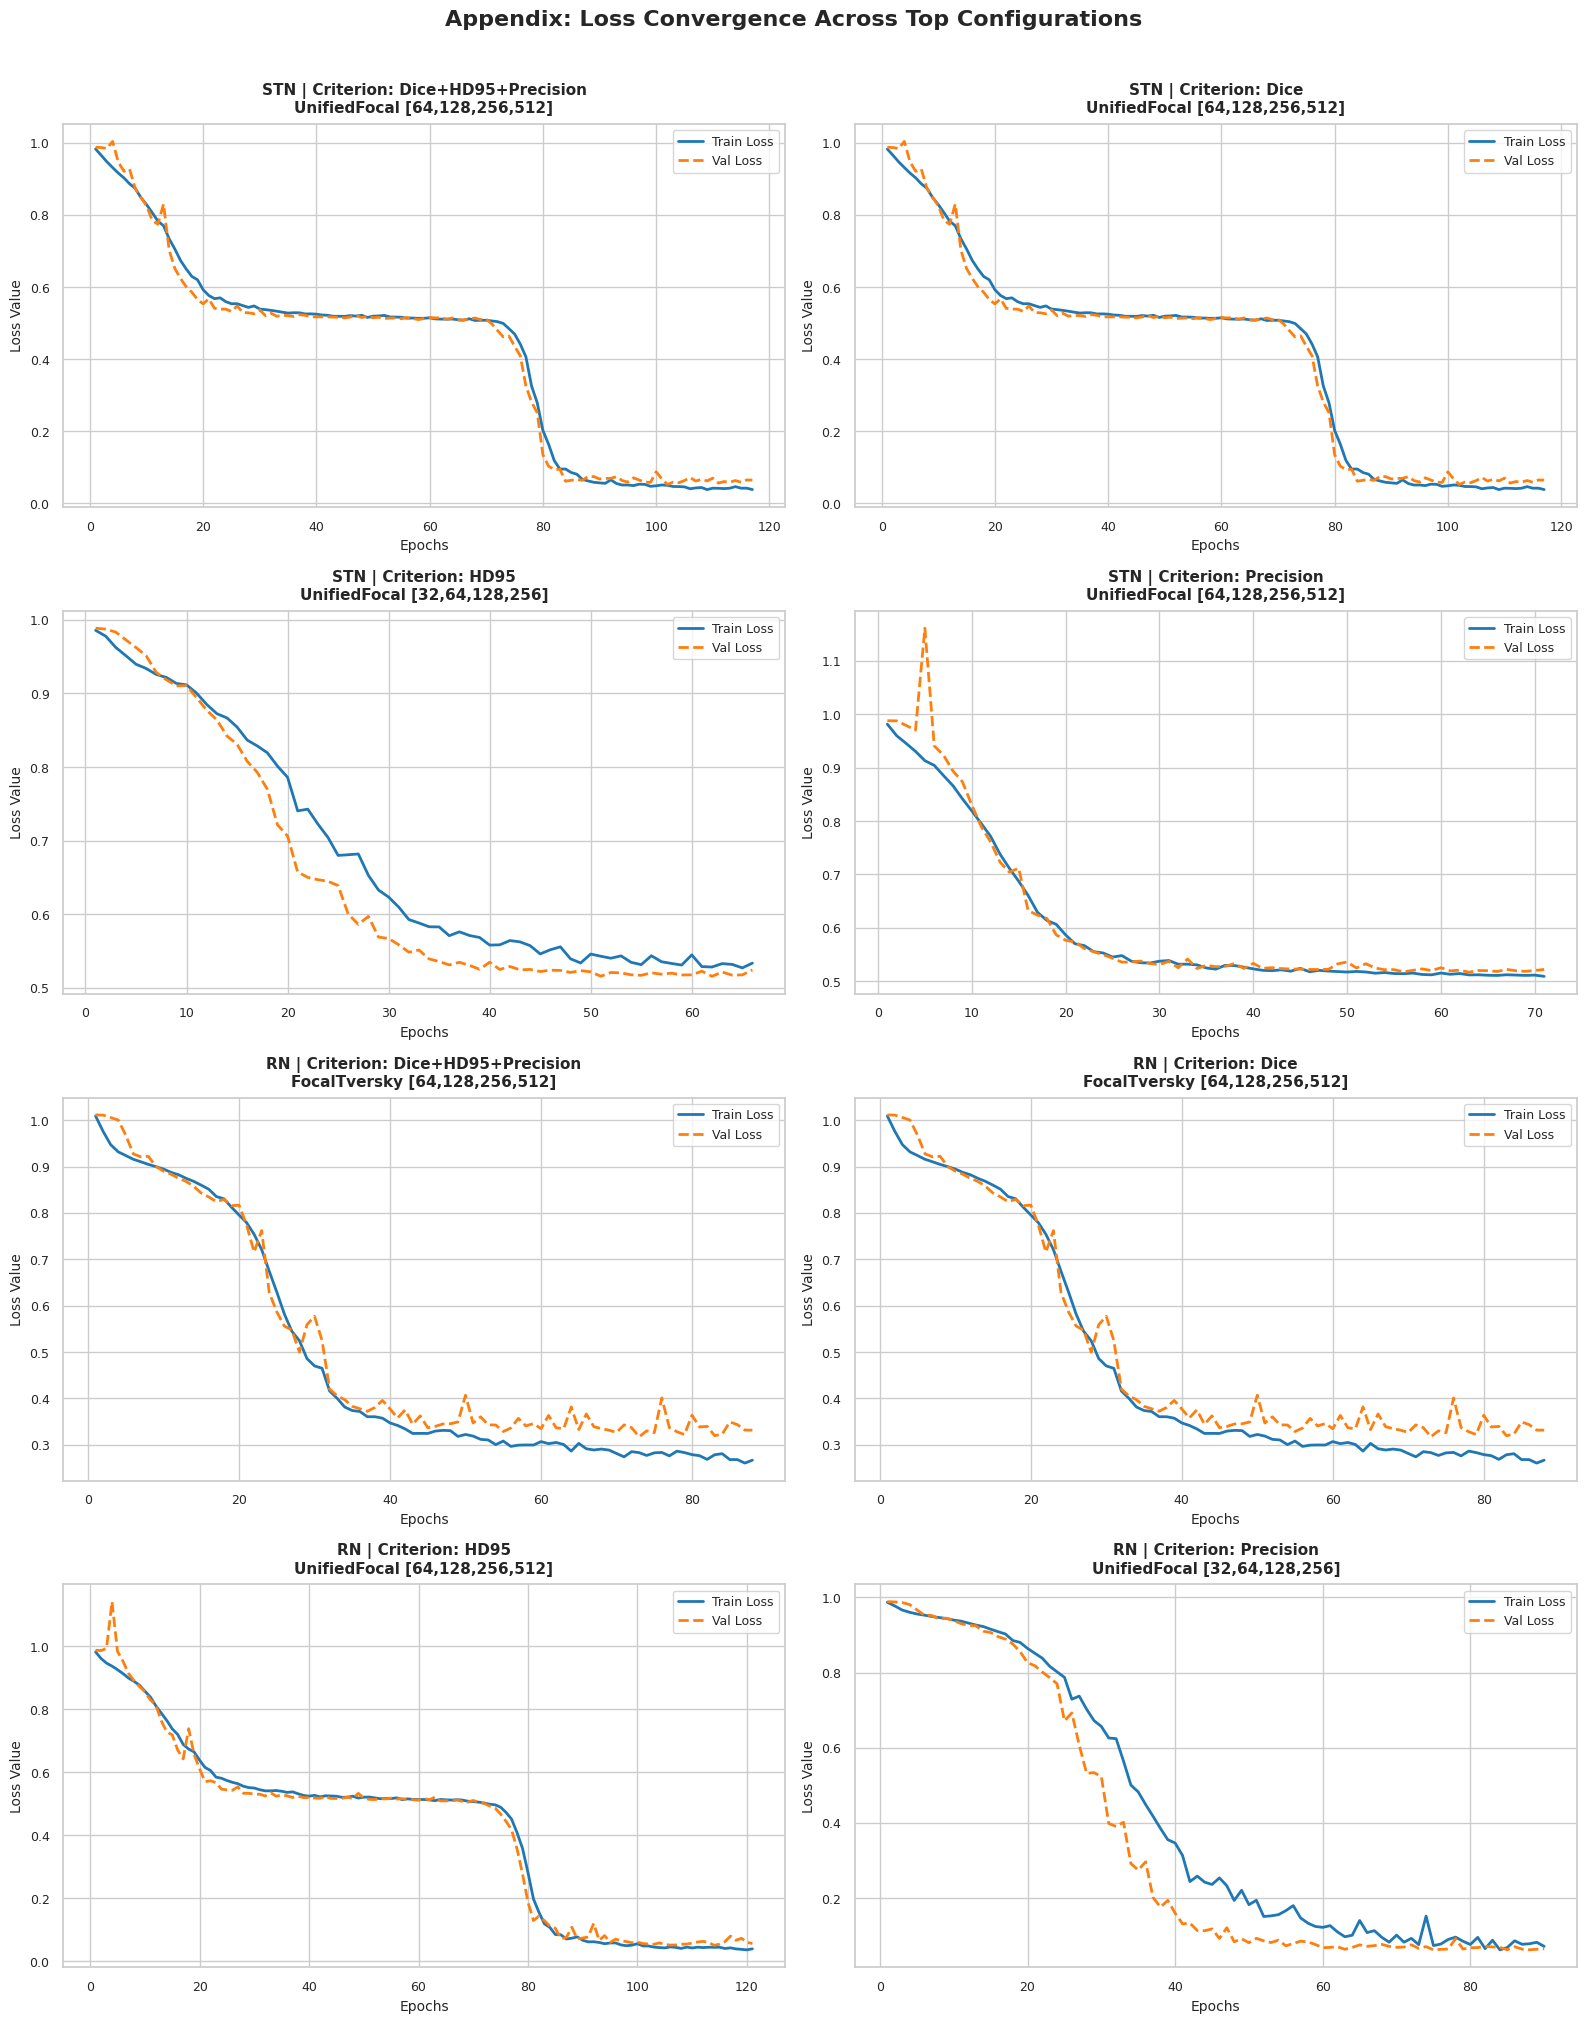

In [11]:
if not os.path.exists(OUTPUT_DIR):
    print(f"Error: The directory {OUTPUT_DIR} does not exist. Check your path!")
else:
    all_folders = os.listdir(OUTPUT_DIR)

    # Create a unified figure with 4 rows and 2 columns
    fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=False)
    axes = axes.flatten()  # Flatten to a 1D array of 8 subplots for easy looping

    for i, run in enumerate(target_runs):
        ax = axes[i]
        
        # Find the folder matching all criteria strings
        matched_folder = None
        for folder in all_folders:
            if all(match in folder for match in run["matches"]):
                matched_folder = folder
                break
        
        if not matched_folder:
            ax.text(0.5, 0.5, f"Missing:\n{run['matches']}", 
                    ha='center', va='center', color='red', fontsize=10)
            ax.set_title(run["label"], fontsize=10, fontweight='bold')
            continue
            
        history_path = os.path.join(OUTPUT_DIR, matched_folder, "history.json")
        
        if not os.path.exists(history_path):
            ax.text(0.5, 0.5, "history.json\nnot found", 
                    ha='center', va='center', color='red', fontsize=10)
            ax.set_title(run["label"], fontsize=10, fontweight='bold')
            continue
            
        with open(history_path, "r") as f:
            history = json.load(f)
            
        epochs = range(1, len(history['train_loss']) + 1)
        
        # Plot Train and Validation losses on the current subplot axis
        ax.plot(epochs, history['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2)
        ax.plot(epochs, history['val_loss'], label='Val Loss', color='#ff7f0e', linestyle='--', linewidth=2)
        
        # Style individual subplot
        ax.set_title(run["label"], fontsize=11, fontweight='bold', pad=8)
        ax.set_xlabel('Epochs', fontsize=10)
        ax.set_ylabel('Loss Value', fontsize=10)
        ax.legend(loc='upper right', frameon=True, fontsize=9)
        ax.tick_params(axis='both', labelsize=9)

    # Global adjustments for the entire figure layout
    plt.suptitle("Appendix: Loss Convergence Across Top Configurations", 
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

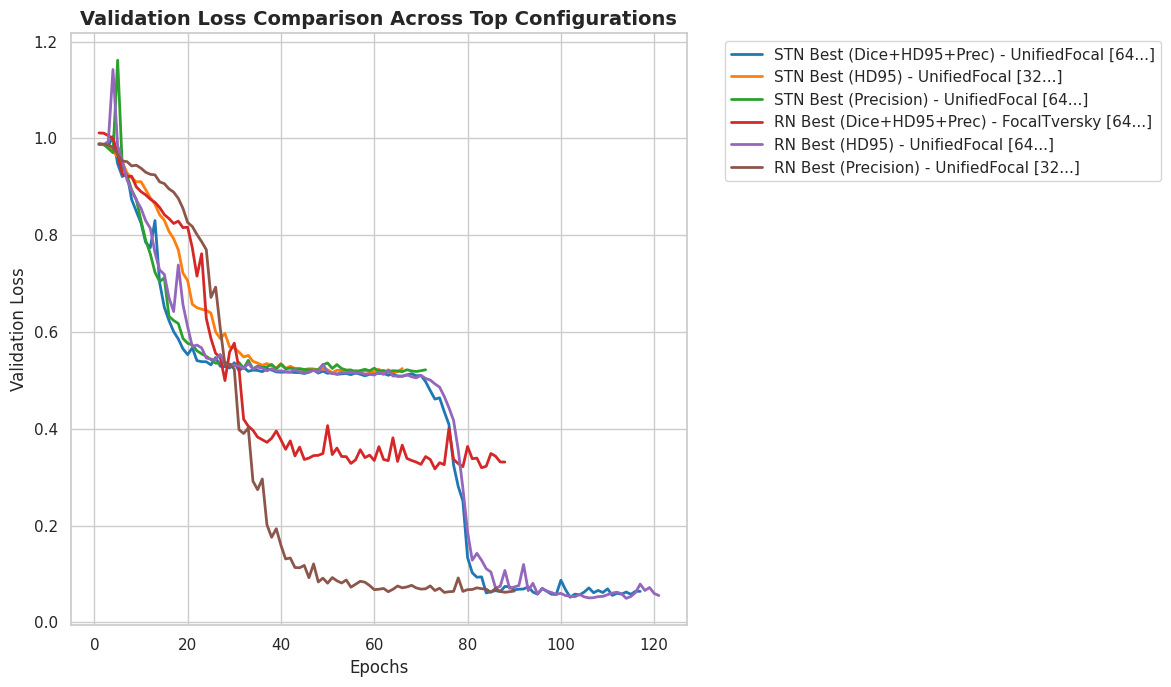

In [4]:
plt.figure(figsize=(12, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, run in enumerate(target_runs):
    for folder in os.listdir(OUTPUT_DIR):
        if all(match in folder for match in run["matches"]):
            history_path = os.path.join(OUTPUT_DIR, folder, "history.json")
            if os.path.exists(history_path):
                with open(history_path, "r") as f:
                    history = json.load(f)
                epochs = range(1, len(history['val_loss']) + 1)
                plt.plot(epochs, history['val_loss'], label=run['label'], color=colors[i % len(colors)], linewidth=2)

plt.title('Validation Loss Comparison Across Top Configurations', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()